In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from pathlib import Path

# Load the cleaned 2025 dataset created in the data preparation stage.
file_path = Path("../data/processed/transportation_2025_clean.parquet")

df=pd.read_parquet(file_path)

# Check the size of the dataset before analysis.
df.shape

(6879485, 34)

In [ ]:
# Business Question 1

# When is the operation most vulnerable to arrival delays?

In [ ]:
# Calculate the overall 15+ minute arrival delay rate.
# This value will be used as the annual benchmark for later comparisons.

overall_delay_rate = df["ArrDel15"].mean()

overall_delay_rate

np.float64(0.2230745794306666)

In [ ]:
# Compare the mean and median of departure and arrival delays
# to determine whether extreme delay values are affecting the average.

df[["DepDelay", "ArrDelay"]].agg(["mean", "median"])

# Large differences between the mean and median suggest that
# a small number of severe delays may pull the mean upward.

,DepDelay,ArrDelay
mean,13.461593,8.504504
median,-2.000000,-6.000000


In [ ]:
# Review the distribution of departure and arrival delay values
# and identify the presence of extreme observations.

df[["DepDelay", "ArrDelay"]].describe()

# The mean is higher than the median because of extreme delay values.
# These values are retained because they may represent real operational events.

,DepDelay,ArrDelay
count,6.879485e+06,6.879484e+06
mean,1.346159e+01,8.504504e+00
std,5.730786e+01,5.973557e+01
min,-1.150000e+02,-1.280000e+02
25%,-6.000000e+00,-1.500000e+01
50%,-2.000000e+00,-6.000000e+00
75%,1.000000e+01,1.100000e+01
max,4.352000e+03,4.336000e+03


In [ ]:
# Examine the upper percentiles to better understand the severity
# of unusually large departure and arrival delays.

df[["DepDelay", "ArrDelay"]].quantile([0.90, 0.95, 0.99, 0.999])

,DepDelay,ArrDelay
0.900,47.000,48.0
0.950,89.000,91.0
0.990,224.000,225.0
0.999,754.516,752.0


In [ ]:
# Calculate the monthly 15+ minute arrival delay rate.

monthly_delay = df.groupby("Month")["ArrDel15"].mean()

monthly_delay

Month
1     0.187892
2     0.207668
3     0.195904
4     0.196639
5     0.236018
6     0.282590
7     0.288853
8     0.225556
9     0.166316
10    0.203220
11    0.205602
12    0.267716
Name: ArrDel15, dtype: float64

In [ ]:
# Compare each month's delay rate with the annual average.
# The result shows how many percentage points each month is above or below
# the overall delay benchmark.

monthly_vs_overall = (
    (monthly_delay - overall_delay_rate) * 100
).sort_values(ascending=False)

monthly_vs_overall

Month
7     6.577794
6     5.951577
12    4.464106
5     1.294305
8     0.248135
2    -1.540694
11   -1.747252
10   -1.985467
4    -2.643601
3    -2.717081
1    -3.518290
9    -5.675836
Name: ArrDel15, dtype: float64

In [ ]:
## Business Question 1
### When is the operation most vulnerable to arrival delays?

# ### Analysis
# Monthly 15+ minute arrival delay rates were compared with the annual average.

# ### Finding
# July had the highest arrival delay rate, at 6.58 percentage points above
# the annual average. June and December also showed relatively high delay rates,
# at 5.95 and 4.46 percentage points above the annual average, respectively.

# September had the lowest delay rate, at 5.68 percentage points below
# the annual average.

# ### Business Interpretation
# Arrival delay risk is concentrated in certain months, with July showing
# the largest deviation from the annual benchmark.

In [ ]:
# Business Question 2

# Which delay causes should be prioritized for operational improvement?

In [ ]:
# Define the delay-cause columns that will be used to measure
# the frequency and total impact of each delay cause.

delay_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

# Count the number of flights where each delay cause contributed
# to a positive amount of delay, and calculate total delay minutes.

delay_counts = (df[delay_columns] > 0).sum()
delay_totals = df[delay_columns].sum()

# Combine occurrence counts and total delay minutes into one summary table.

delay_summary = pd.DataFrame({
    "Count": delay_counts,
    "TotalDelayMinutes": delay_totals
})

delay_summary

,Count,TotalDelayMinutes
CarrierDelay,805311,36326377.0
WeatherDelay,100103,7108714.0
NASDelay,793120,24483761.0
SecurityDelay,5100,152802.0
LateAircraftDelay,774405,43862971.0


In [ ]:
# Rank delay causes by their total contribution to delay minutes.

delay_summary.sort_values("TotalDelayMinutes", ascending=False)

,Count,TotalDelayMinutes
LateAircraftDelay,774405,43862971.0
CarrierDelay,805311,36326377.0
NASDelay,793120,24483761.0
WeatherDelay,100103,7108714.0
SecurityDelay,5100,152802.0


In [ ]:
# Calculate the percentage of total delay minutes contributed by each delay cause.
# This allows the causes to be compared based on their overall impact.

percentage_of_cause = (
    (delay_totals/delay_totals.sum())*100.
).sort_values(ascending=False)

percentage_of_cause

LateAircraftDelay    39.186240
CarrierDelay         32.453208
NASDelay             21.873268
WeatherDelay          6.350773
SecurityDelay         0.136510
dtype: float64

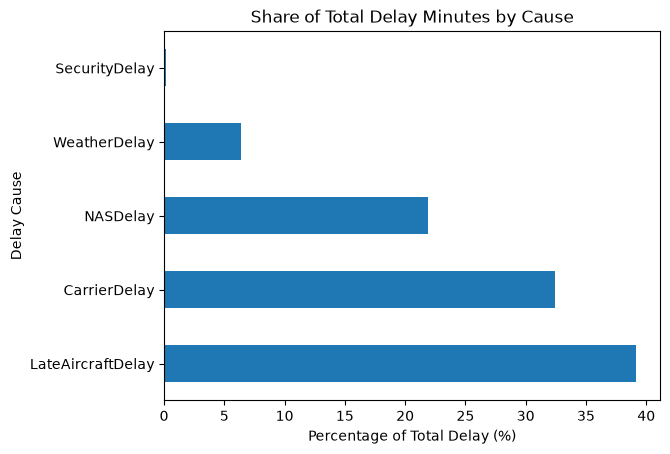

In [ ]:
# Visualize the share of total delay minutes contributed by each delay cause.

percentage_of_cause.plot(
    kind="barh",
    title="Share of Total Delay Minutes by Cause"
)

plt.xlabel("Percentage of Total Delay (%)")
plt.ylabel("Delay Cause")
plt.show()

In [ ]:
## Business Question 2
### Which delay causes should be prioritized for operational improvement?

# ### Finding
# Late Aircraft Delay had the largest share of total delay minutes at about 37%.
# Carrier Delay was the second largest contributor at about 31%, followed by NAS Delay.

# ### Interpretation
# This shows that Late Aircraft Delay had the biggest overall impact on delays in 2025.
# Carrier Delay also occurred frequently, so it may be another important area to investigate.

# ### Recommendation
# I would focus on Late Aircraft Delay first and then Carrier Delay,
# since they had the largest overall impact on total delay time.

In [ ]:
# Business Question 3

# Which routes have the highest arrival delay rates?

In [ ]:
# Calculate the 15+ minute arrival delay rate and flight count for each route.
# Routes with fewer than 100 flights are excluded to reduce the effect of small samples.

route_delay = (
    df.groupby("Route")["ArrDel15"]
      .agg(["mean", "count"])
      .query("count >= 100")
      .sort_values("mean", ascending=False)
)

route_delay.head(10)

,mean,count
Route,,
ROA-SFB,0.672000,125
TRI-SFB,0.642276,123
CKB-SFB,0.616071,112
LEX-SFB,0.613636,220
TOL-SFB,0.585586,111
SFB-ROA,0.584000,125
SFB-USA,0.580808,198
CHA-SFB,0.568182,132
SFB-GSP,0.566372,113


In [ ]:
## Business Question 3
### Which routes have the highest arrival delay rates?

# ### Finding
# Several routes had relatively high 15+ minute arrival delay rates.
# ROA-SFB had the highest rate at about 67%, followed by TRI-SFB and CKB-SFB.

# SFB appeared frequently among the routes with the highest delay rates,
# which suggests that routes involving this airport may need further investigation.

# ### Interpretation
# The results show that arrival delays are not evenly distributed across routes.
# Some routes have much higher delay rates than the overall average.

# However, these results do not by themselves explain why these routes have
# higher delay rates. Further analysis would be needed to identify the factors
# behind the pattern.

# ### Recommendation
# Routes with consistently high delay rates should receive additional
# operational review, especially those involving SFB.

In [ ]:
# Business Question 4

# Which airlines perform above or below the overall delay benchmark?

In [ ]:
# Calculate the 15+ minute arrival delay rate for each airline.

airline_delay = df.groupby("Reporting_Airline")["ArrDel15"].mean()

# Compare each airline's delay rate with the overall annual benchmark.
# Positive values indicate performance above the overall delay rate,
# while negative values indicate performance below it.

airline_vs_overall = (
    (airline_delay - overall_delay_rate) * 100
).sort_values(ascending=False)

airline_vs_overall

Reporting_Airline
F9    5.604094
OH    5.222308
B6    3.844821
AA    3.403967
G4    2.657898
AS    0.793312
YX   -0.796156
UA   -0.840019
NK   -0.899023
WN   -0.912405
MQ   -1.268172
OO   -1.585744
DL   -2.513241
HA   -5.026308
Name: ArrDel15, dtype: float64

In [ ]:
## Business Question 4
### Which airlines perform above or below the overall delay benchmark?

# ### Finding
# F9 had the highest arrival delay rate relative to the overall average,
# with a rate 5.60 percentage points above the benchmark.

# OH, B6, and AA were also above the overall average.
# On the other hand, HA had the lowest rate, at 5.03 percentage points below
# the overall average.

# ### Interpretation
# There is a noticeable difference in delay performance across airlines.
# Some airlines performed consistently better or worse than the overall benchmark.

# ### Recommendation
# Airlines with higher-than-average delay rates could be reviewed further
# to identify operational factors that may be contributing to the difference.

In [ ]:
# 3-5 Recommendations

# ### 1. Focus on Late Aircraft Delays
# Late Aircraft Delay accounted for the largest share of total delay minutes.
# This should be the first area to investigate because it had the biggest overall impact.

# ### 2. Pay More Attention to High-Risk Periods
# July had the highest arrival delay rate, and delays were also higher during
# late-afternoon and evening departure hours. These periods could receive
# additional operational monitoring.

# ### 3. Review High-Risk Routes
# Some routes had much higher delay rates than the overall average.
# Routes involving SFB appeared frequently among the highest-delay routes,
# so they may need further review.

# ### 4. Review Airlines Above the Benchmark
# F9, OH, B6, and AA had higher 15+ minute arrival delay rates than the overall
# average. These airlines could be reviewed further to understand what factors
# may be contributing to the difference.